In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
from scipy.stats import chi2_contingency
from dataset_analyze import *

wr.filterwarnings('ignore')

# Upload dataset
df = pd.read_csv("Dataset/in-vehicle-coupon-recommendation.csv")
df_synthetic = pd.read_csv("Dataset/synthetic_1x.csv")

print("Veri seti başarıyla yüklendi!")
print(f"Veri Seti Boyutu: {df.shape}, Sentetik Veri Seti Boyutu: {df_synthetic.shape}")

Veri seti başarıyla yüklendi!
Veri Seti Boyutu: (12684, 26), Sentetik Veri Seti Boyutu: (10088, 22)


In [21]:
def analyze_dataset():
    display(df.head()) 
    print(f"Shape of the dataset: {df.shape}\n")
    print("--- Dataset Info ---")
    df.info()
    print("\n--- Statistical Summary ---")
    display(df.describe().T)
    print("Missing values:\n" + str(df.isnull().sum()))
    print("\nDuplicate values: " + str(df.duplicated().sum()))
    print("\nTarget Distribution (Y):\n" + str(df['Y'].value_counts(normalize=True) * 100))

# Fonksiyonu çalıştırmak için:
analyze_dataset()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


Shape of the dataset: (12684, 26)

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar     

,count,mean,std,min,25%,50%,75%,max
temperature,12684.0,63.301798,19.154486,30.0,55.0,80.0,80.0,80.0
has_children,12684.0,0.414144,0.492593,0.0,0.0,0.0,1.0,1.0
toCoupon_GEQ5min,12684.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
toCoupon_GEQ15min,12684.0,0.561495,0.496224,0.0,0.0,1.0,1.0,1.0
toCoupon_GEQ25min,12684.0,0.119126,0.323950,0.0,0.0,0.0,0.0,1.0
direction_same,12684.0,0.214759,0.410671,0.0,0.0,0.0,0.0,1.0
direction_opp,12684.0,0.785241,0.410671,0.0,1.0,1.0,1.0,1.0
Y,12684.0,0.568433,0.495314,0.0,0.0,1.0,1.0,1.0


Missing values:
destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

Duplicate values: 74

Target Distribution (Y):
Y
1    56.843267
0    43.156733
Name: proportion, dtype: float64


In [3]:
print("\n--- Synthetic Dataset Statistical Summary ---")
display(df_synthetic.describe().T)
print("\nTarget Distribution (Y):\n" + str(df_synthetic['Y'].value_counts(normalize=True) * 100))


--- Synthetic Dataset Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
temperature,10088.0,63.401071,19.172970,30.0,55.0,80.0,80.0,80.0
has_children,10088.0,0.404044,0.490730,0.0,0.0,0.0,1.0,1.0
toCoupon_GEQ15min,10088.0,0.567605,0.495433,0.0,0.0,1.0,1.0,1.0
toCoupon_GEQ25min,10088.0,0.120044,0.325029,0.0,0.0,0.0,0.0,1.0
Y,10088.0,0.569191,0.495214,0.0,0.0,1.0,1.0,1.0



Target Distribution (Y):
Y
1    56.919112
0    43.080888
Name: proportion, dtype: float64


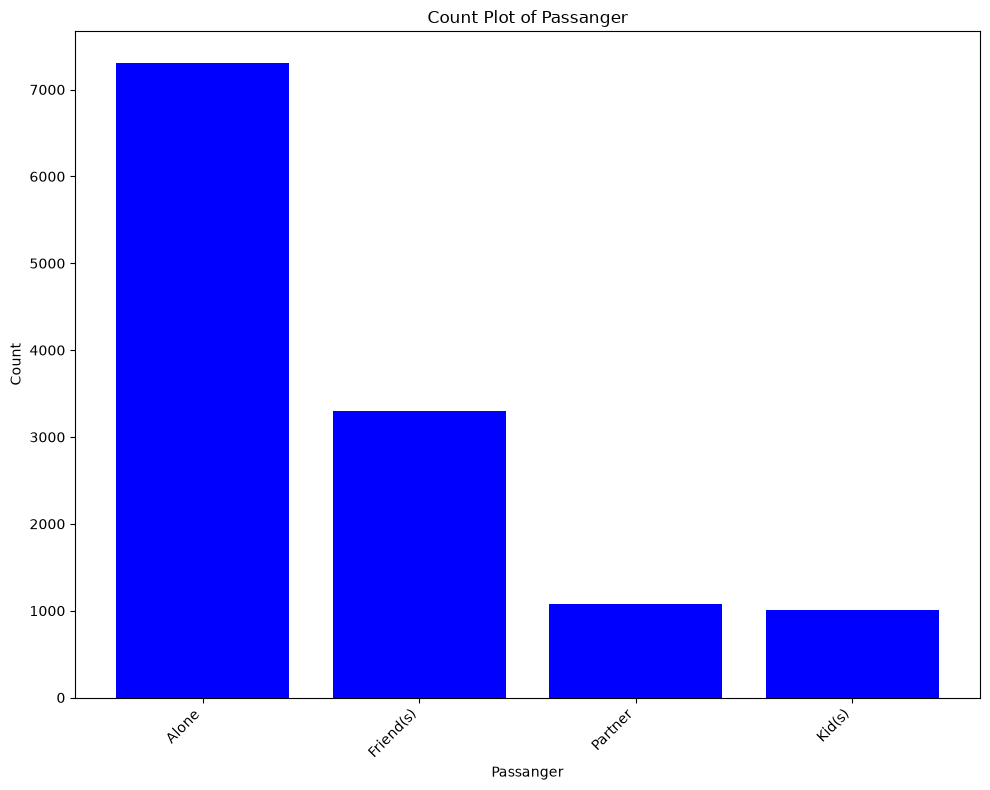

In [22]:
def barPlot_dataset(columnName, fig_width=10):
    column_counts = df[columnName].value_counts()

    if df[columnName].dtype == 'int64':
        raw_labels = [str(val) for val in column_counts.sort_index().index]
    else:
        raw_labels = column_counts.index

    num_categories = len(raw_labels)
    max_chars = max(3, int((fig_width * 10) / num_categories)) if num_categories > 0 else 10
        
    x_labels = [label_str[:max_chars] + "..." if len(label_str := str(label)) > max_chars else label_str for label in raw_labels]

    plt.figure(figsize=(10, 8))
    plt.bar(x_labels, column_counts, color="blue")
    plt.title(f'Count Plot of {columnName.capitalize()}')
    plt.xlabel(f'{columnName.capitalize()}')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# Örnek kullanım (İstediğin sütun adını yazarak çalıştırabilirsin):
barPlot_dataset('passanger')

Grafik kaydedildi: Results/Version1/Bivariate/acceptance_by_weather.png


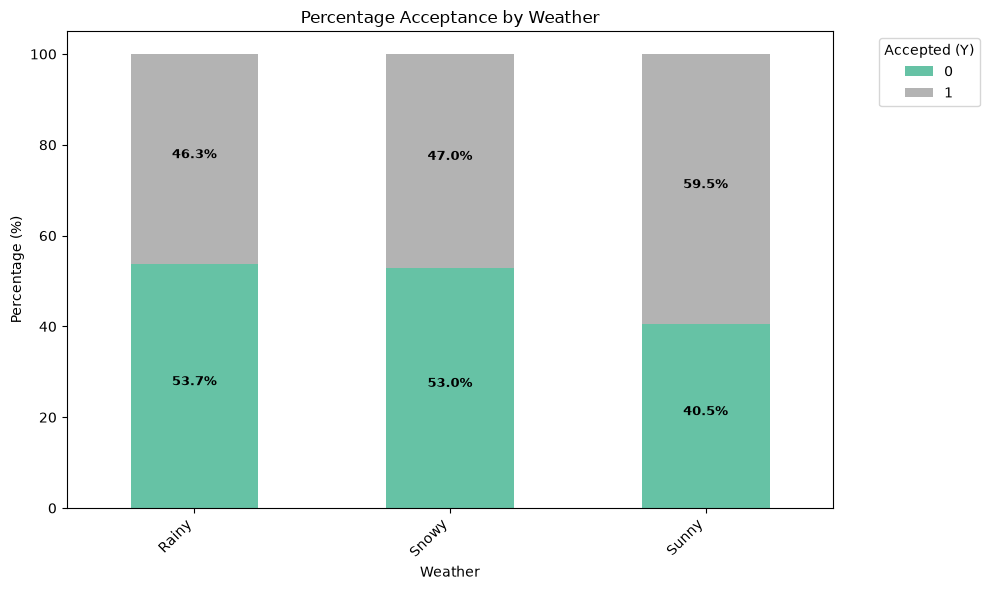

In [23]:
def univariate_analysis(column, save_path="Results/Version1/Bivariate"):
    # Çapraz tabloyu yüzdelik olarak hesapla
    ct = pd.crosstab(df[column], df["Y"], normalize="index") * 100

    # 1. Figür ve eksenleri açıkça tanımlıyoruz (fazladan figür oluşmasını engeller)
    fig, ax = plt.subplots(figsize=(10, 6))

    # Grafiği ax üzerine çizdiriyoruz
    ct.plot(kind="bar", stacked=True, ax=ax, colormap="Set2")

    plt.title(f"Percentage Acceptance by {column.capitalize()}")
    plt.xlabel(column.capitalize())
    plt.ylabel("Percentage (%)")
    plt.legend(title="Accepted (Y)", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.xticks(rotation=45, ha="right")

    # --- Barların Üzerine Yüzdelik Değerleri Yazdırma (0 ve 1 için) ---
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            label_type="center",
            fontsize=9,
            color="black",
            weight="bold",
            padding=3,
        )

    # Otomatik klasör oluşturma ve kaydetme
    os.makedirs(save_path, exist_ok=True)
    file_name = f"{save_path}/acceptance_by_{column}.png"

    plt.tight_layout()
    plt.savefig(file_name, dpi=300, bbox_inches="tight")
    print(f"Grafik kaydedildi: {file_name}")

    # Göster ve hafızayı temizle (fazladan boş figür çıkmasını önler)
    plt.show()
    plt.close(fig)

# Örnek kullanım:
univariate_analysis('weather')

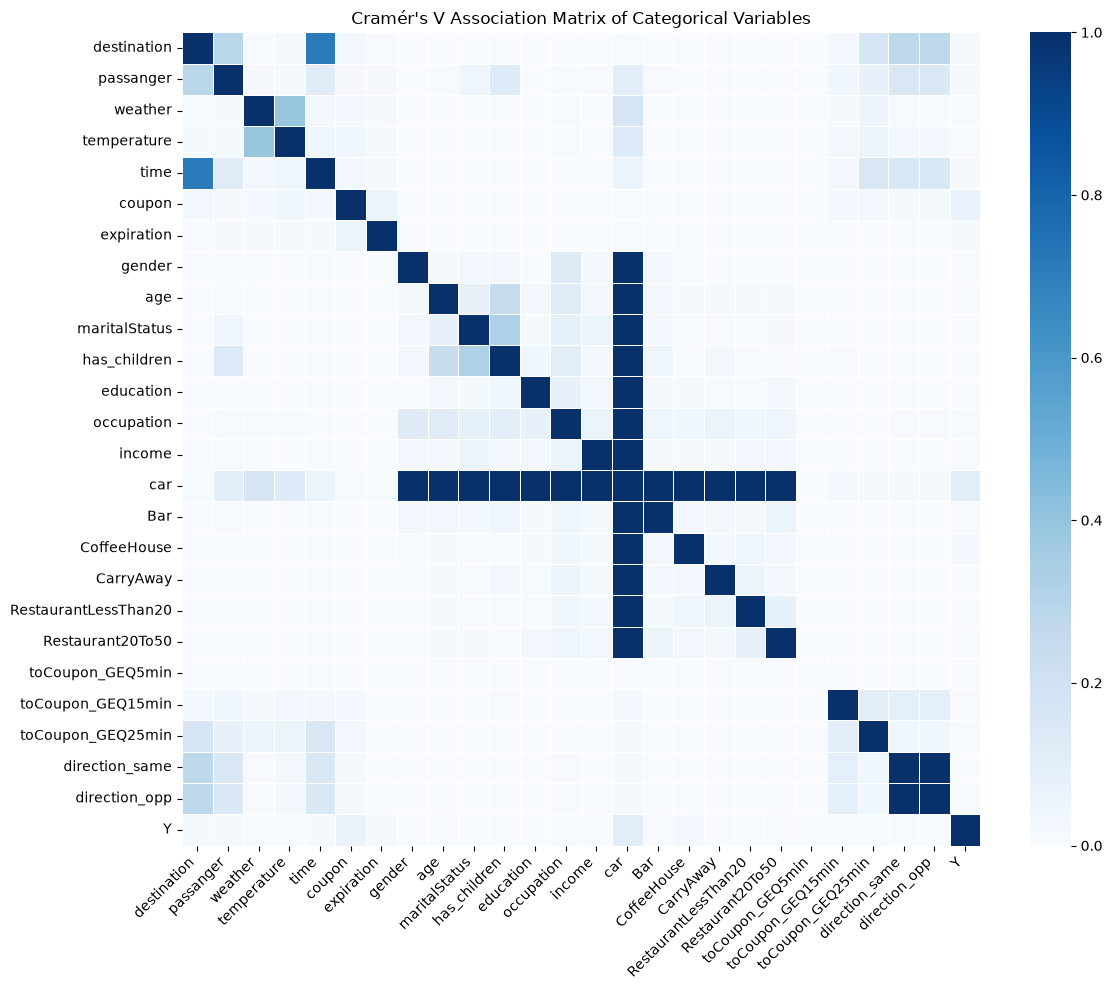

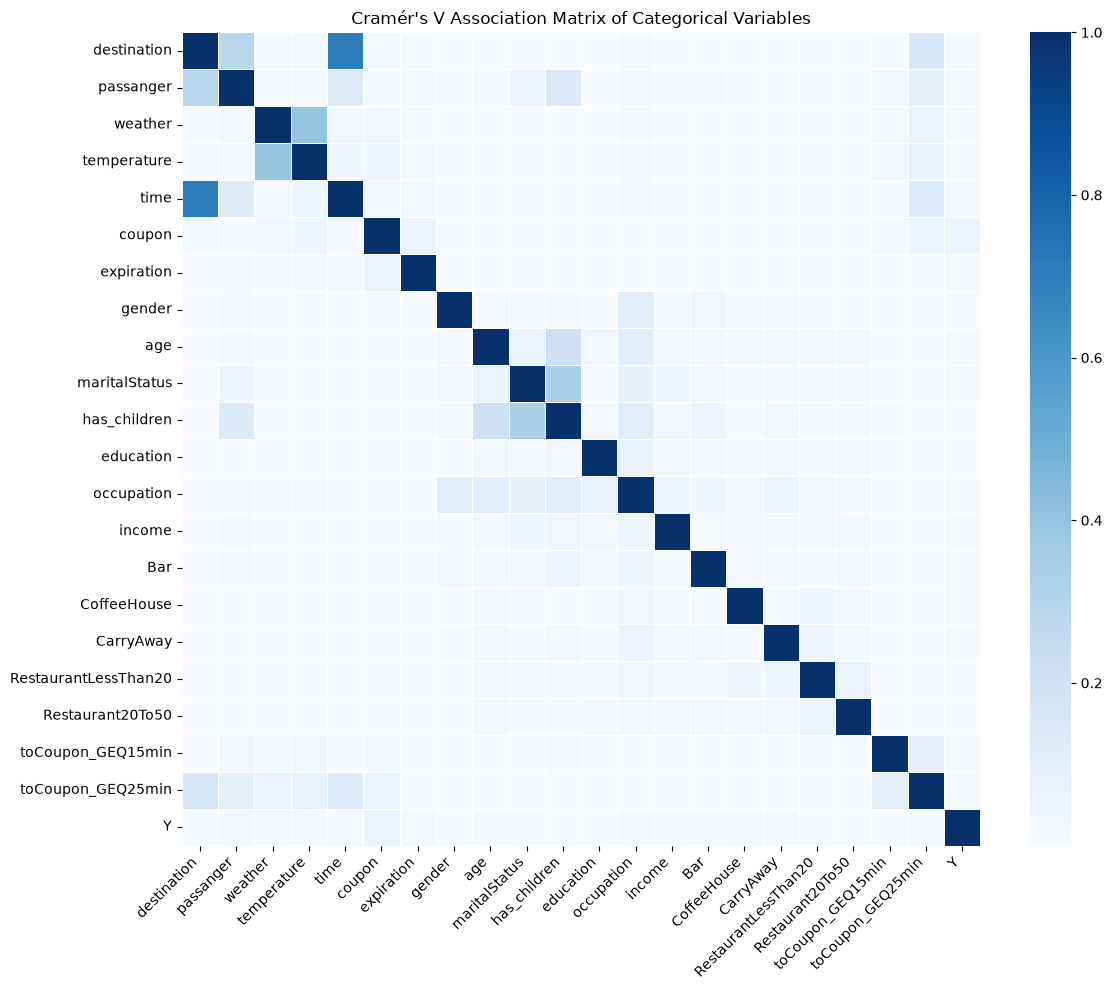

In [4]:
def calculate_cramers_v(series1, series2):
    confusion_matrix = pd.crosstab(series1, series2)
    chi2, _, _, _ = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape

    if r <= 1 or k <= 1 or n == 0:
        return 0.0

    return (chi2 / n) / min(k - 1, r - 1)

def plot_cramers_v_matrix(df):
    columns = df.columns
    cramers_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)
    
    for col1 in columns:
        for col2 in columns:
            cramers_matrix.loc[col1, col2] = calculate_cramers_v(df[col1], df[col2])

    cramers_matrix = cramers_matrix.astype(float)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cramers_matrix,
        annot=False,
        cmap="Blues",
        cbar=True,
        linewidths=0.5,
    )   
    plt.title("Cramér's V Association Matrix of Categorical Variables")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Çalıştırmak için:
plot_cramers_v_matrix(df)
plot_cramers_v_matrix(df_synthetic)

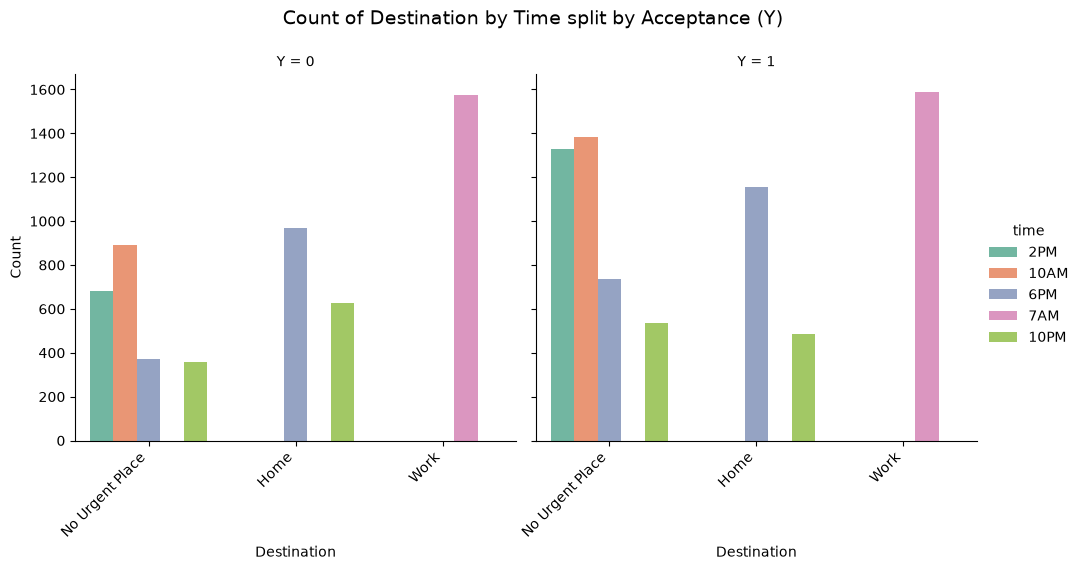

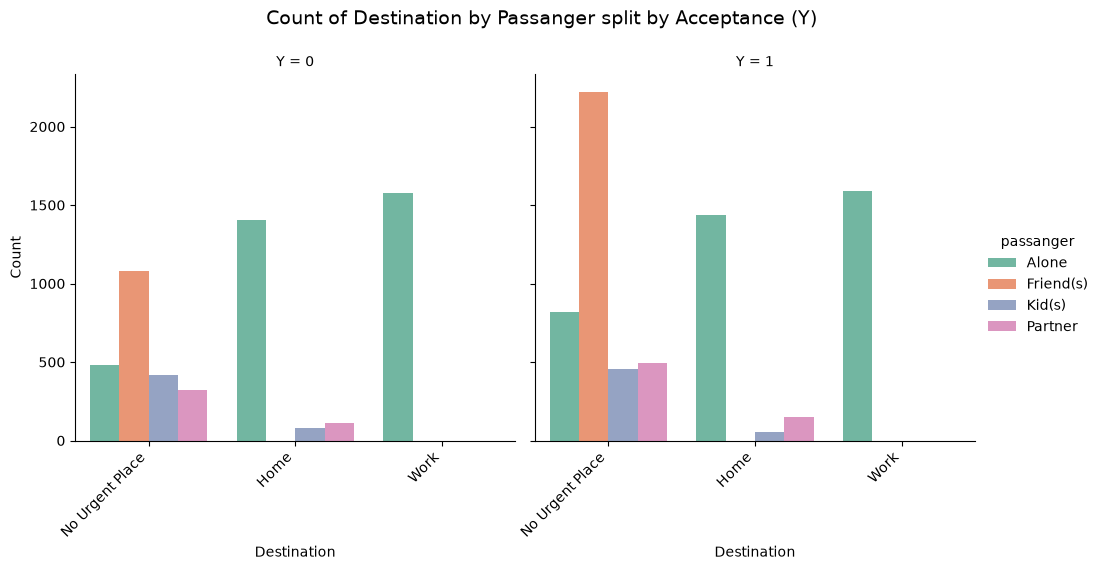

In [26]:
def faceted_bivariate_analysis(
    x_col, hue_col, save_path="Results/Analyze/Version1/Faceted_Bivariate"):

  g = sns.catplot(
      data=df,
      x=x_col,
      hue=hue_col,
      col="Y",  # Y sütununa göre grafikleri yan yana ayırır (Y=0 ve Y=1)
      kind="count",  # Sayım grafiği (count plot)
      height=5,
      aspect=1,
      palette="Set2",
  )

  # Grafik başlıklarını ve etiketlerini düzenleme
  g.set_axis_labels(x_col.capitalize(), "Count")
  g.set_titles(col_template="Y = {col_name}")
  g.fig.subplots_adjust(top=0.85)  # Üst başlık için pay bırak
  g.fig.suptitle(
      f"Count of {x_col.capitalize()} by {hue_col.capitalize()} split by Acceptance (Y)",
      fontsize=14,
  )

  for ax in g.axes.flat:
    for label in ax.get_xticklabels():
      label.set_rotation(45)
      label.set_ha("right")

  os.makedirs(save_path, exist_ok=True)
  file_name = f"{save_path}/count_{x_col}_by_{hue_col}_split_by_Y.png"

  g.savefig(file_name, dpi=300, bbox_inches="tight")

  plt.show()

faceted_bivariate_analysis(x_col="destination", hue_col="time")
faceted_bivariate_analysis(x_col="destination", hue_col="passanger")

In [8]:
def calculate_missing_lift(target_column, feature_to_check):
    missing_subset = df[df[target_column].isnull()]
    missing_dist = missing_subset[feature_to_check].value_counts(normalize=True) * 100

    overall_dist = df[feature_to_check].value_counts(normalize=True) * 100

    comparison = pd.DataFrame(
        {
            "Boş Bırakanlar (%)": missing_dist,
            "Tüm Veri Seti (%)": overall_dist,
        }
    )

    comparison["Oran (Lift)"] = (
        comparison["Boş Bırakanlar (%)"] / comparison["Tüm Veri Seti (%)"]
    )

    print(f"--- '{target_column}' Eksikliği ve '{feature_to_check}' Orantılama Analizi ---")
    display(round(comparison, 2))
    print("\n" + "=" * 50 + "\n")

# Betiğindeki döngüyü doğrudan burada koşturabilirsin:
target_cols = ['Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50']

for col in df.columns:
    calculate_missing_lift('Restaurant20To50', col)

--- 'Restaurant20To50' Eksikliği ve 'destination' Orantılama Analizi ---


,Boş Bırakanlar (%),Tüm Veri Seti (%),Oran (Lift)
destination,,,
No Urgent Place,58.20,49.53,1.17
Home,21.69,25.52,0.85
Work,20.11,24.94,0.81




--- 'Restaurant20To50' Eksikliği ve 'passanger' Orantılama Analizi ---


,Boş Bırakanlar (%),Tüm Veri Seti (%),Oran (Lift)
passanger,,,
Alone,53.97,57.59,0.94
Friend(s),26.98,26.00,1.04
Kid(s),12.17,7.93,1.53
Partner,6.88,8.48,0.81




--- 'Restaurant20To50' Eksikliği ve 'weather' Orantılama Analizi ---


...

,Boş Bırakanlar (%),Tüm Veri Seti (%),Oran (Lift)
direction_same,,,
0,79.89,78.52,1.02
1,20.11,21.48,0.94




--- 'Restaurant20To50' Eksikliği ve 'direction_opp' Orantılama Analizi ---


,Boş Bırakanlar (%),Tüm Veri Seti (%),Oran (Lift)
direction_opp,,,
1,79.89,78.52,1.02
0,20.11,21.48,0.94




--- 'Restaurant20To50' Eksikliği ve 'Y' Orantılama Analizi ---


,Boş Bırakanlar (%),Tüm Veri Seti (%),Oran (Lift)
Y,,,
1,55.56,56.84,0.98
0,44.44,43.16,1.03
